# Methods

In [32]:
import pandas as pd
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from xgboost import XGBClassifier

from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.adversarial import AdversarialFairnessClassifier
import tensorflow as tf


In [ ]:
df = pd.read_pickle("df.pkl")
df_nosens = pd.read_pickle("df_nosens.pkl")

In [2]:
df.head()

,los,gender,age_18-29,age_30-49,age_50-64,age_65-79,age_80-91,race_ASIAN,race_BLACK,race_EUROPEAN,...,lab_max_51006_missing,lab_max_51221_missing,lab_max_51222_missing,lab_max_51265_missing,lab_count_50912_missing,lab_count_51006_missing,lab_count_51221_missing,lab_count_51222_missing,lab_count_51265_missing,icu_mortality
0,0.410266,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,1,0,0,1,1,1,0
1,3.893252,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.497535,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,1,1,1,1,1,1,1,1,0
3,1.118032,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.948113,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


## Second Model: XGBoost

In [43]:
# Functions re-used from LR method
def create_df_test(df, X_test, y_true, y_pred, y_score):
    df_test = df.loc[X_test.index].copy()
    df_test['y_true'] = y_true
    df_test['y_pred'] = y_pred
    df_test['y_score'] = y_score.clip(0, 1)

    gender_map = {1: 'Male', 0: 'Female'}
    age_cols = ['age_18-29', 'age_30-49', 'age_50-64', 'age_65-79', 'age_80-91']
    race_cols = ['race_ASIAN', 'race_BLACK', 'race_EUROPEAN', 'race_HISPANIC/LATINO',
                'race_OTHER', 'race_RUSSIAN', 'race_UNKNOWN', 'race_WHITE']
    
    df_test['gender_group'] = df_test['gender'].map(gender_map)
    df_test['age_group'] = df_test[age_cols].idxmax(axis=1).str.replace('age_', '')
    df_test['race_group'] = df_test[race_cols].idxmax(axis=1).str.replace('race_', '')

    return df_test

def get_group_metrics(df_subset, group_col):
    metrics_list = []
    for group in df_subset[group_col].unique():
        group_df = df_subset[df_subset[group_col] == group]
        report = classification_report(
            group_df['y_true'], group_df['y_pred'],
            output_dict=True, zero_division=0
        )
        tn, fp, fn, tp = confusion_matrix(group_df['y_true'], group_df['y_pred']).ravel()
        metrics_list.append({
            'group': group,
            'support': report['1']['support'],
            'precision': report['1']['precision'],
            'recall (TPR)': report['1']['recall'],
            'f1_score': report['1']['f1-score'],
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
            'PPR': group_df['y_pred'].mean()
        })
    return pd.DataFrame(metrics_list)

def plot_equal_opportunity(df, metric='recall (TPR)', title='', figsize=(7, 5)):
    plt.figure(figsize=figsize)
    
    # subtitle
    gap_dict = {}
    for model in df['model'].unique():
        group_df = df[df['model'] == model]
        gap = group_df[metric].max() - group_df[metric].min()
        gap_dict[model] = gap
    
    subtitle = "Gap " + " | ".join([f"{model}: {gap:.3f}" for model, gap in gap_dict.items()])

    
    ax = sns.barplot(data=df, x='group', y=metric, hue='model', palette='pastel')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle(subtitle, fontsize=10, y=0.86, color='gray')

    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')

    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.1%}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=8, color='black')

    plt.tight_layout()
    plt.show()

    return gap_dict

def plot_statistical_parity(df, title='', figsize=(7, 5)):
    plt.figure(figsize=figsize)
    
    # subtitle
    gap_texts = []
    gap_dict = {}
    for model in df['model'].unique():
        group_df = df[df['model'] == model]
        gap = group_df['PPR'].max() - group_df['PPR'].min()
        gap_texts.append(f"{model}: {gap:.3f}")
        gap_dict[model] = gap

    subtitle = "Gap " + " | ".join(gap_texts)


    ax = sns.barplot(data=df, x='group', y='PPR', hue='model', palette='pastel')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle(subtitle, fontsize=10, y=0.86, color='gray')

    ax.set_ylabel('Positive Prediction Rate', fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')

    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.1%}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=7, color='black')

    plt.tight_layout()
    plt.show()

    return gap_dict

def plot_equalized_odds(df, group_col_name, title_prefix, figsize=(15, 5)):
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=False)

    # subtitles
    tpr_gap_texts = []
    fpr_gap_texts = []
    tpr_gap_dict = {}
    fpr_gap_dict = {}

    for model in df['model'].unique():
        model_df = df[df['model'] == model]
        tpr_gap = model_df['recall (TPR)'].max() - model_df['recall (TPR)'].min()
        fpr_gap = model_df['FPR'].max() - model_df['FPR'].min()
        tpr_gap_texts.append(f"{model}: {tpr_gap:.3f}")
        fpr_gap_texts.append(f"{model}: {fpr_gap:.3f}")
        tpr_gap_dict[model] = tpr_gap
        fpr_gap_dict[model] = fpr_gap


    axs[0].text(0.5, 0.95, "TPR Gap " + " | ".join(tpr_gap_texts),
                fontsize=10, color='gray', ha='center', transform=axs[0].transAxes)

    axs[1].text(0.5, 0.95, "FPR Gap " + " | ".join(fpr_gap_texts),
                fontsize=10, color='gray', ha='center', transform=axs[1].transAxes)


    # TPR
    sns.barplot(data=df, x='group', y='recall (TPR)', hue='model', palette='pastel', ax=axs[0])
    axs[0].set_title(f'{title_prefix} - True Positive Rate (Recall)', fontsize=12)
    axs[0].set_xlabel(group_col_name)
    axs[0].tick_params(axis='x', rotation=20)
    axs[0].set_ylabel('TPR')
    axs[0].set_ylim(0, 1)
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # Annotate the bar
    for container in axs[0].containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                axs[0].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=9)

    # FPR
    sns.barplot(data=df, x='group', y='FPR', hue='model', palette='pastel', ax=axs[1])
    axs[1].set_title(f'{title_prefix} - False Positive Rate (FPR)', fontsize=12)
    axs[1].set_xlabel(group_col_name)
    axs[1].tick_params(axis='x', rotation=20)
    axs[1].set_ylabel('FPR')
    axs[1].set_ylim(0, 1)
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # Annotate the bar
    for container in axs[1].containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                axs[1].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.show()

    return tpr_gap_dict, fpr_gap_dict

def compute_ece(y_true, y_score, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_indices = np.digitize(y_score, bins) - 1
    ece = 0.0

    for i in range(n_bins):
        mask = bin_indices == i
        if np.any(mask):
            bin_confidence = y_score[mask].mean()
            bin_accuracy = y_true[mask].mean()
            bin_size = mask.sum() / len(y_true)
            ece += bin_size * np.abs(bin_confidence - bin_accuracy)
    
    return ece

def plot_calibration_ece(df, model_label, n_bins=10, figsize=(15, 5)):
    fig, axs = plt.subplots(1, 3, figsize=figsize)

    group_cols = ['gender_group', 'age_group', 'race_group']
    titles = ['Gender Group', 'Age Group', 'Race Group']
    avg_subgroup_ece = {}

    for i, (group_col, title) in enumerate(zip(group_cols, titles)):
        ax = axs[i]
        group_df = df
        subgroups = sorted(group_df[group_col].unique())

        subgroup_ece_list = []
        subgroup_labels = []
        

        for subgroup in subgroups:
            subgroup_df = group_df[group_df[group_col] == subgroup]
            y_true = subgroup_df['y_true']
            y_score = subgroup_df['y_score']
            
            subgroup_ece = compute_ece(y_true, y_score)
            subgroup_ece_list.append(subgroup_ece)
            
            prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=n_bins, strategy='uniform')
            ax.plot(prob_pred, prob_true, marker='o')
            subgroup_labels.append(f'{subgroup} (ECE={subgroup_ece:.3f})')

        
        avg_subgroup_ece[group_col] = np.mean(subgroup_ece_list)


        ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
        ax.set_xlabel('Mean Predicted Probability')
        ax.set_ylabel('Observed Fraction of Positives')
        ax.set_title(f'{title}\nAvg ECE = {avg_subgroup_ece[group_col]:.3f}', fontsize=11)
        ax.grid(True)
        ax.legend(subgroup_labels, fontsize=7, title='Group')

    plt.suptitle(f'{model_label} Model - Calibration Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return avg_subgroup_ece


def plot_roc_auc(y_true, y_scores, label='Model', color='blue', ax=None):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC = {auc_score:.2f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curve')
    ax.grid(True)

    return auc_score, ax

def plot_pr_and_find_best_threshold(y_true, y_scores, label='Model', color='black', ax=None):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)
    ap_score = average_precision_score(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    ax.plot(recall, precision, color=color, label=f'{label} (Avg Precision = {ap_score:.2f}, Best Thresh = {best_threshold:.2f})')
    ax.scatter(recall[best_idx], precision[best_idx], color='red', s=40)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve')
    ax.grid(True)

    print(f"\n{label}")
    print(f"Best threshold based on F1 score: {best_threshold:.3f}")
    print(f"Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}, F1: {best_f1:.3f}")

    y_pred = (y_scores >= best_threshold).astype(int)
    return best_threshold, y_pred, auc_score, best_f1, ax


### Baseline & Full models

In [ ]:
# --- Prepare splits & scalers ---
def prepare_data(df, drop_sens):
    X = df.drop(columns=['icu_mortality'])
    if drop_sens:
        # drop sensitive columns in baseline
        sens = ['gender'] + \
              [c for c in df.columns if c.startswith('age_')] + \
              [c for c in df.columns if c.startswith('race_')]
        X = X.drop(columns=sens, errors='ignore')
    y = df['icu_mortality']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=35
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test

# Baseline (no sensitive)
Xtr_b, Xte_b, Xtr_b_s, Xte_b_s, ytr_b, yte_b = prepare_data(df_nosens, drop_sens=True)
# Full (with sensitive)
Xtr_f, Xte_f, Xtr_f_s, Xte_f_s, ytr_f, yte_f = prepare_data(df, drop_sens=False)

#### Train XGBoost classifiers

In [ ]:
def train_xgb(X_train, y_train):
    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=35,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model

xgb_b = train_xgb(Xtr_b_s, ytr_b)
xgb_f = train_xgb(Xtr_f_s, ytr_f)


# ---  Predictions & Probabilities ---
y_pred_b = xgb_b.predict(Xte_b_s)
y_proba_b = xgb_b.predict_proba(Xte_b_s)[:,1]
y_pred_f = xgb_f.predict(Xte_f_s)
y_proba_f = xgb_f.predict_proba(Xte_f_s)[:,1]


# --- Reports ---
print("=== XGBoost Baseline (No Sensitives) ===")
print(classification_report(yte_b, y_pred_b, digits=3))
print("AUC:", roc_auc_score(yte_b, y_proba_b))

print("\n=== XGBoost Full (With Sensitives) ===")
print(classification_report(yte_f, y_pred_f, digits=3))
print("AUC:", roc_auc_score(yte_f, y_proba_f))

c:\Users\Cynthia\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:32:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Cynthia\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:32:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost Baseline (No Sensitives) ===
              precision    recall  f1-score   support

           0      0.966     0.987     0.976     17339
           1      0.806     0.611     0.695      1550

    accuracy                          0.956     18889
   macro avg      0.886     0.799     0.836     18889
weighted avg      0.953     0.956     0.953     18889

AUC: 0.948150486782547

=== XGBoost Full (With Sensitives) ===
              precision    recall  f1-score   support

           0      0.967     0.987     0.977     17339
           1      0.816     0.625     0.708      1550

    accuracy                          0.958     18889
   macro avg      0.892     0.806     0.843     18889
weighted avg      0.955     0.958     0.955     18889

AUC: 0.9503250736266741


#### plot ROC Curves


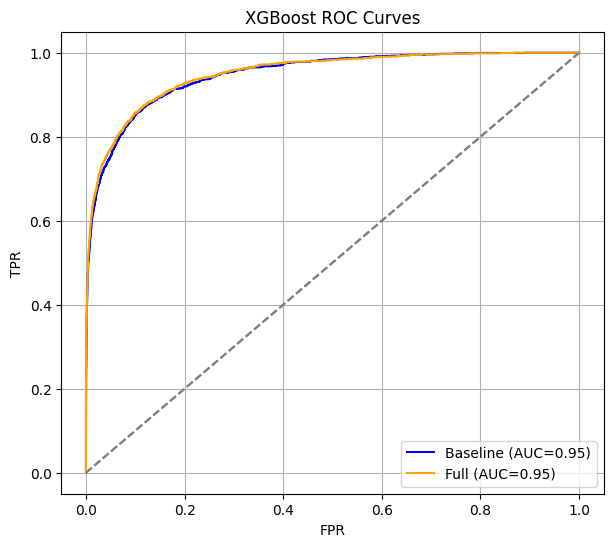

In [11]:
def plot_roc(y_true, y_scores, label, color, ax):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    ax.plot(fpr, tpr, color=color, label=f"{label} (AUC={auc:.2f})")
    ax.plot([0,1],[0,1],'--', color='gray')
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.grid(True)
    return auc

fig, ax = plt.subplots(figsize=(7,6))
auc_b = plot_roc(yte_b, y_proba_b, "Baseline", "blue", ax)
auc_f = plot_roc(yte_f, y_proba_f, "Full"    , "orange", ax)
ax.legend(); plt.title("XGBoost ROC Curves"); plt.show()

#### Precision-Recall & Best Thresholds

Baseline best thresh=0.304  Prec=0.717  Rec=0.682  F1=0.699
Full best thresh=0.420  Prec=0.791  Rec=0.650  F1=0.714


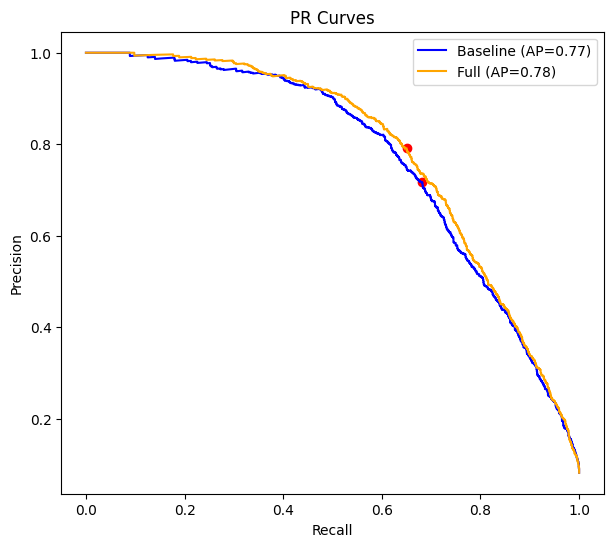

In [14]:
def plot_pr_find_thresh(y_true, y_scores, label, color, ax):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1)
    best_thresh = thresholds[best_idx]
    ap = average_precision_score(y_true, y_scores)
    ax.plot(recall, precision, color=color, label=f"{label} (AP={ap:.2f})")
    ax.scatter(recall[best_idx], precision[best_idx], color='red')
    print(f"{label} best thresh={best_thresh:.3f}  Prec={precision[best_idx]:.3f}  Rec={recall[best_idx]:.3f}  F1={f1[best_idx]:.3f}")
    return best_thresh

fig, ax = plt.subplots(figsize=(7,6))
th_b = plot_pr_find_thresh(yte_b, y_proba_b, "Baseline", "blue", ax)
th_f = plot_pr_find_thresh(yte_f, y_proba_f, "Full"    , "orange", ax)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(); plt.title("PR Curves"); plt.show()

# apply thresholds
y_pred_b_th = (y_proba_b >= th_b).astype(int)
y_pred_f_th = (y_proba_f >= th_f).astype(int)


#### Final Confusion Matrices

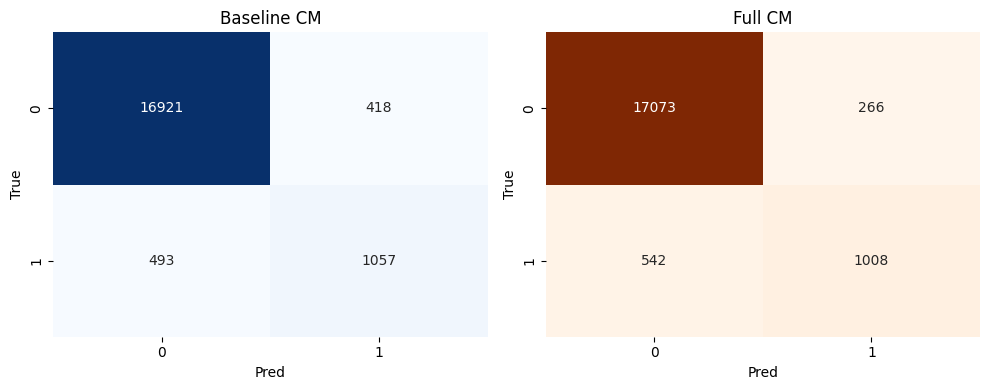

In [17]:
fig, axs = plt.subplots(1,2,figsize=(10,4))
cm_b = confusion_matrix(yte_b, y_pred_b_th)
cm_f = confusion_matrix(yte_f, y_pred_f_th)

sns.heatmap(cm_b, annot=True, fmt='d', ax=axs[0], cmap='Blues', cbar=False)
axs[0].set_title("Baseline CM"); 
axs[0].set_xlabel("Pred"); 
axs[0].set_ylabel("True")

sns.heatmap(cm_f, annot=True, fmt='d', ax=axs[1], cmap='Oranges', cbar=False)
axs[1].set_title("Full CM"); 
axs[1].set_xlabel("Pred"); 
axs[1].set_ylabel("True")

plt.tight_layout(); plt.show()


### Fairness Diagnosis

In [22]:
# build df_test for each
df_test_b = create_df_test(df, Xte_b, yte_b, y_pred_b_th, y_proba_b)
df_test_f = create_df_test(df, Xte_f, yte_f, y_pred_f_th, y_proba_f)

# group metrics
gender_b = get_group_metrics(df_test_b, 'gender_group'); gender_b['model']='Baseline'
age_b    = get_group_metrics(df_test_b, 'age_group');    age_b['model']='Baseline'
race_b   = get_group_metrics(df_test_b, 'race_group');   race_b['model']='Baseline'

gender_f = get_group_metrics(df_test_f, 'gender_group'); gender_f['model']='Full'
age_f    = get_group_metrics(df_test_f, 'age_group');    age_f['model']='Full'
race_f   = get_group_metrics(df_test_f, 'race_group');   race_f['model']='Full'

gender_cmp = pd.concat([gender_b, gender_f])
age_cmp    = pd.concat([age_b, age_f])
race_cmp   = pd.concat([race_b, race_f])


#### Equal Opportunity
All groups should have equal TPR (recall).

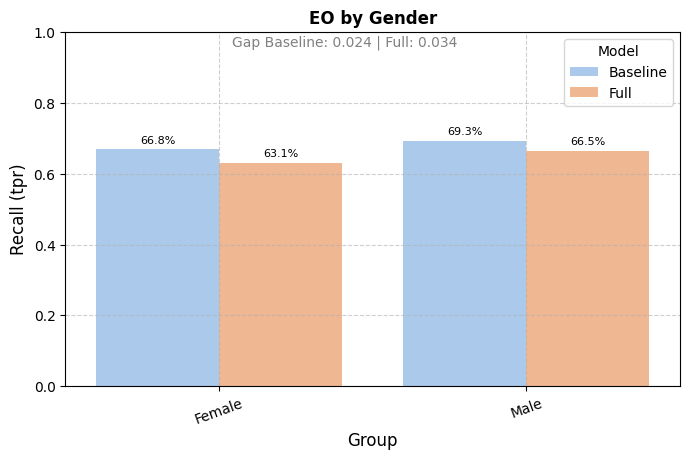

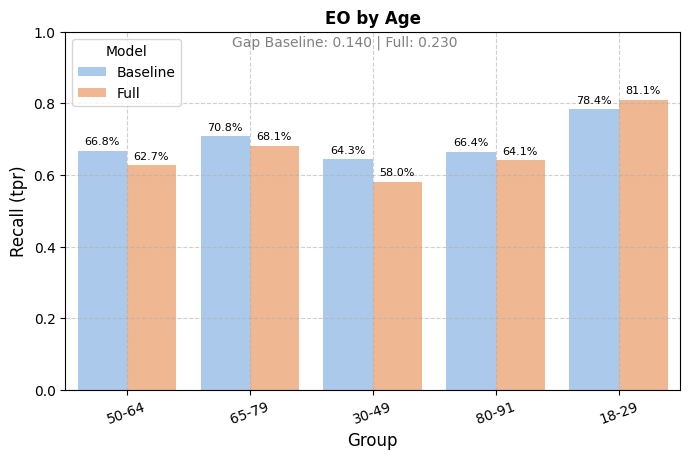

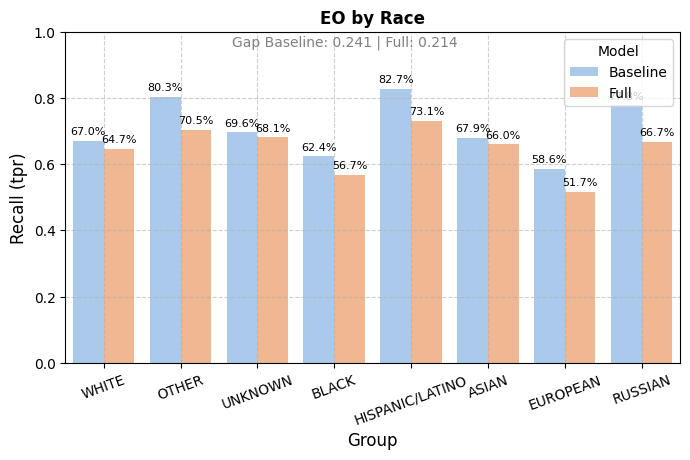

In [ ]:
_ = plot_equal_opportunity(gender_cmp, metric='recall (TPR)', title='Equal Opportunity by Gender')
_ = plot_equal_opportunity(age_cmp, metric='recall (TPR)', title='Equal Opportunity by Age')
_ = plot_equal_opportunity(race_cmp, metric='recall (TPR)', title='Equal Opportunity by Race')

#### Statistical Parity (Positive Prediction Rate)

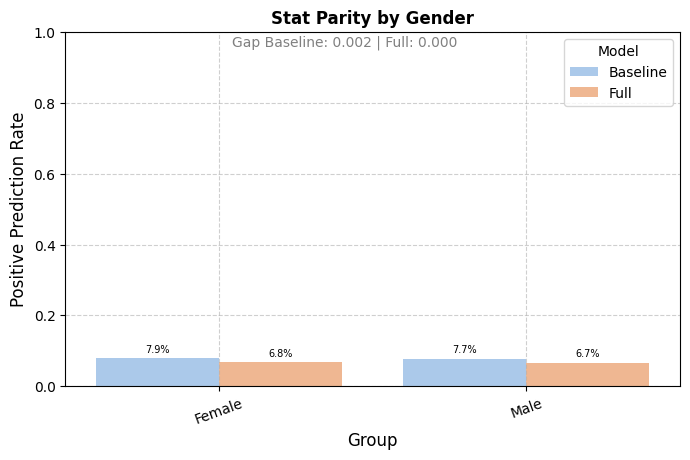

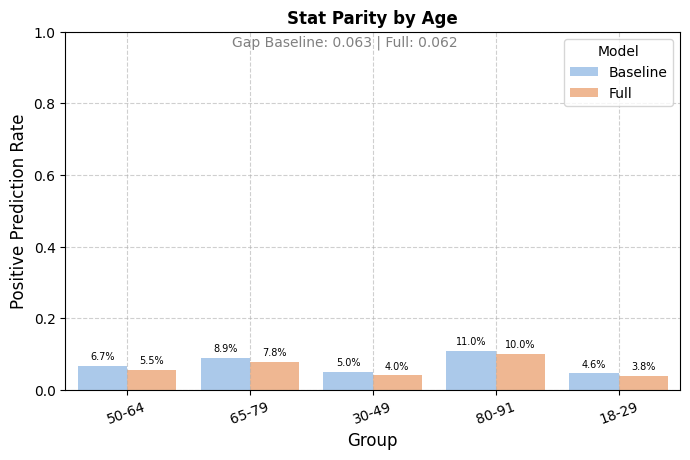

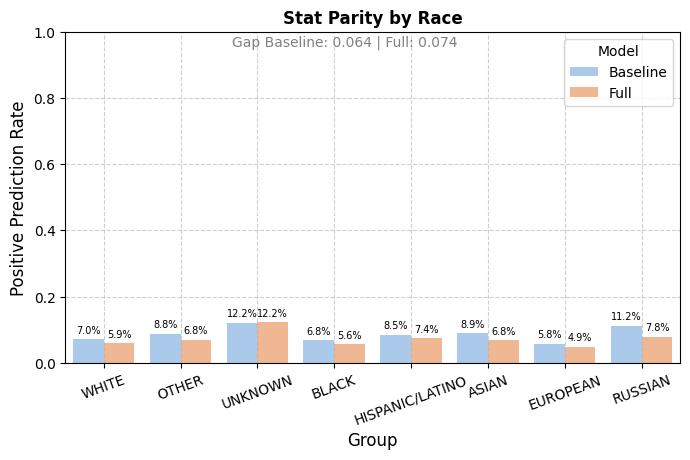

In [ ]:
_ = plot_statistical_parity(gender_cmp, title='Stat Parity by Gender')
_ = plot_statistical_parity(age_cmp, title='Stat Parity by Age')
_ = plot_statistical_parity(race_cmp, title='Stat Parity by Race')

#### Equaliezed Odds - TPR, FPR

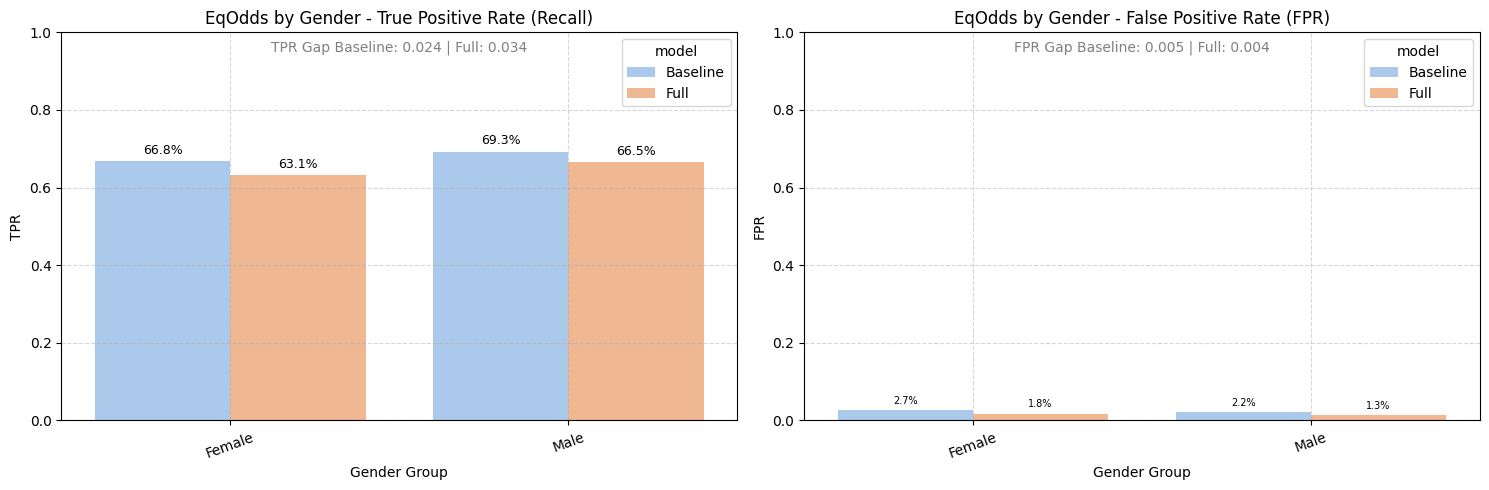

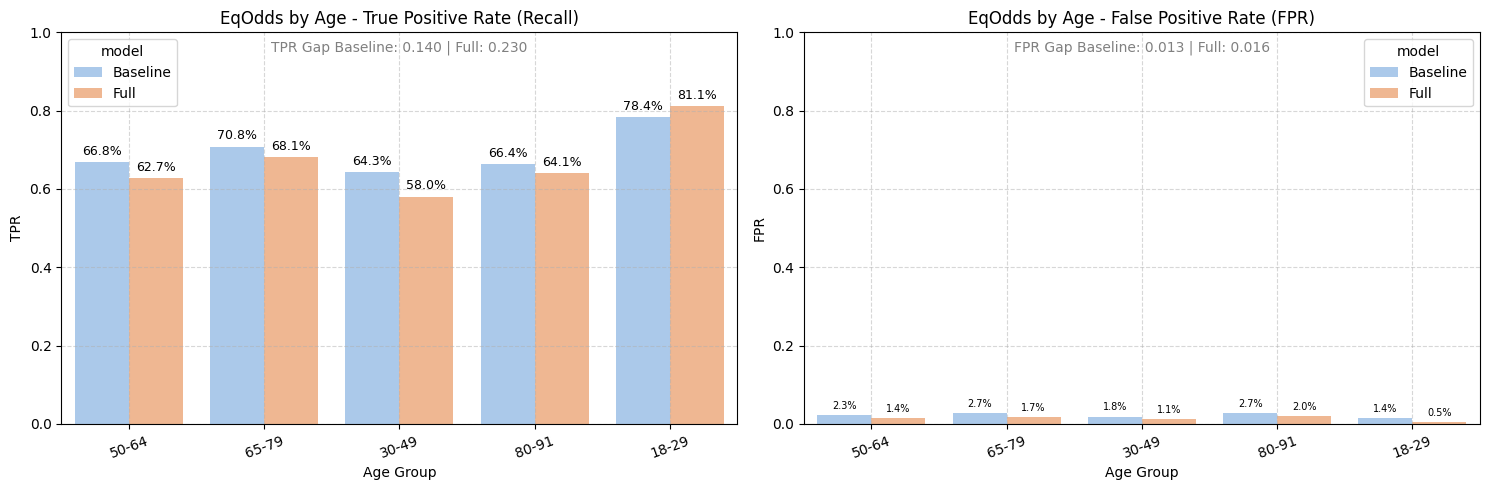

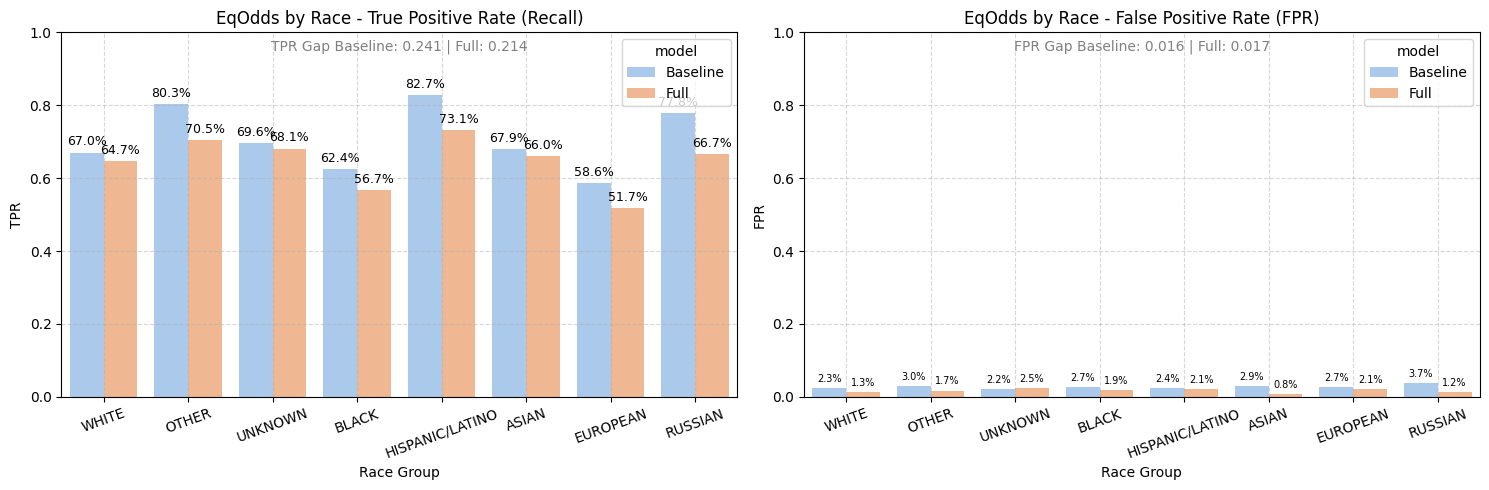

In [ ]:
_ = plot_equalized_odds(gender_cmp, 'Gender Group', title_prefix='Equalized Odds by Gender')
_ = plot_equalized_odds(age_cmp, 'Age Group', title_prefix='Equalized Odds by Age')
_ = plot_equalized_odds(race_cmp, 'Race Group', title_prefix='Equalized Odds by Race')

#### Calibration - The predicted probability reflects reality

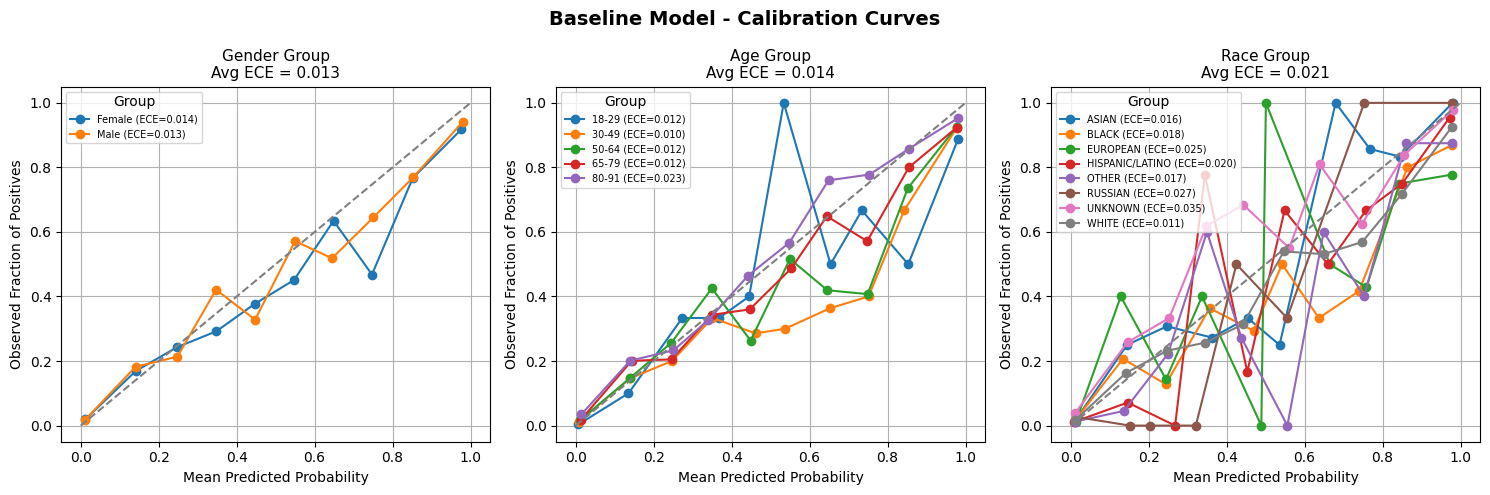

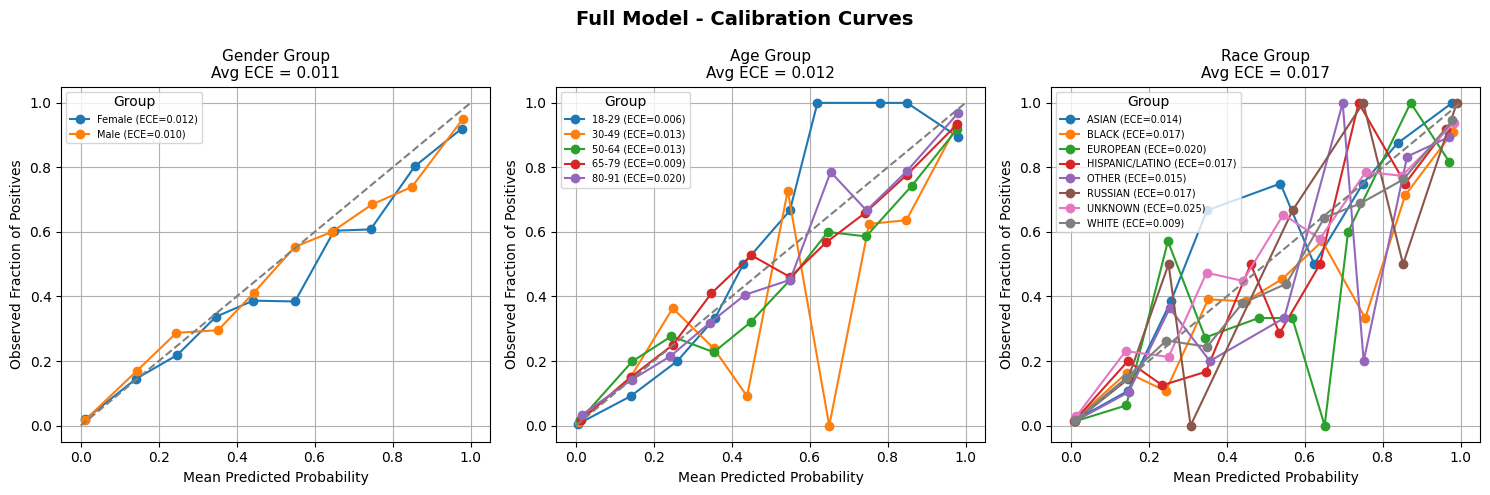

In [31]:
_ = plot_calibration_ece(df_test_b, model_label='Baseline')
_ = plot_calibration_ece(df_test_f, model_label='Full')

### Bias Mitigation

In [33]:
# --- prepare df_dummy ---
df_dummy = df.copy()
age_cols  = ['age_18-29','age_30-49','age_50-64','age_65-79','age_80-91']
race_cols = ['race_ASIAN','race_BLACK','race_EUROPEAN','race_HISPANIC/LATINO',
             'race_OTHER','race_RUSSIAN','race_UNKNOWN','race_WHITE']

df_dummy['age_group'] = df_dummy[age_cols].idxmax(axis=1).str.replace('age_','')
df_dummy['race_group'] = df_dummy[race_cols].idxmax(axis=1).str.replace('race_','')
df_dummy['gender_group'] = df_dummy['gender'].map({0:'Female',1:'Male'})

# reweighting intersection group (gender, age, race)
df_dummy['intersection_group'] = (
    df_dummy[['gender','race_group','age_group']].astype(str).agg('-'.join,axis=1)
)
counts = df_dummy['intersection_group'].value_counts()
group_weights = (1/counts).div((1/counts).sum())
df_dummy['group_weight'] = df_dummy['intersection_group'].map(group_weights)


#### Bias Mitigation 1
- apply SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance in the ICU mortality label  
- reweighting  

In [34]:
# 1a) train/test split 
# keep all features, including sensitives here; 
# will be dropped inside SMOTE step
X = df.drop(columns='icu_mortality')
y = df['icu_mortality']
w = df_dummy['group_weight']

X_tr1, X_te1, y_tr1, y_te1, w_tr1, w_te1 = train_test_split(
    X, y, w, random_state=35, stratify=y, test_size=0.2
)

# 1b) scale
scaler1 = StandardScaler().fit(X_tr1)
X_tr1_s = scaler1.transform(X_tr1)
X_te1_s = scaler1.transform(X_te1)

# 1c) manual SMOTE upsampling on the TRAIN set
df_sm1 = pd.DataFrame(X_tr1_s, columns=X.columns)
df_sm1['y']      = y_tr1.reset_index(drop=True)
df_sm1['weight'] = w_tr1.reset_index(drop=True)

pos = df_sm1[df_sm1['y']==1]
neg = df_sm1[df_sm1['y']==0]
pos_up = pos.sample(len(neg), replace=True, random_state=35)
sm1    = pd.concat([neg, pos_up], axis=0).sample(frac=1, random_state=35)

X_sm1 = sm1.drop(columns=['y','weight']).values
y_sm1 = sm1['y'].values
w_sm1 = sm1['weight'].values

# 1d) XGBoost fit with sample weights
xgb1 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=35)
xgb1.fit(X_sm1, y_sm1, sample_weight=w_sm1)

y_pred_bm1  = xgb1.predict(X_te1_s)
y_proba_bm1 = xgb1.predict_proba(X_te1_s)[:,1]

print("=== BM1: XGB + SMOTE + Reweight ===")
print(classification_report(y_te1, y_pred_bm1, digits=3))
print("AUC:", roc_auc_score(y_te1, y_proba_bm1))


c:\Users\Cynthia\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:31:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== BM1: XGB + SMOTE + Reweight ===
              precision    recall  f1-score   support

           0      0.984     0.887     0.933     17339
           1      0.400     0.843     0.543      1550

    accuracy                          0.883     18889
   macro avg      0.692     0.865     0.738     18889
weighted avg      0.936     0.883     0.901     18889

AUC: 0.9423807229274301


#### Bias Mitigation 2
- ExponentiatedGradient with regularization  

In [37]:
# 2a) split with race_group as sensitive feature
X = df.drop(columns='icu_mortality')
y = df['icu_mortality']
s = df_dummy['race_group']

X_tr2, X_te2, y_tr2, y_te2, s_tr2, s_te2 = train_test_split(
    X, y, s, random_state=35, stratify=y, test_size=0.2
)

# 2b) scale
scaler2   = StandardScaler().fit(X_tr2)
X_tr2_s   = scaler2.transform(X_tr2)
X_te2_s   = scaler2.transform(X_te2)

# 2c) SMOTE on TRAIN
df_sm2 = pd.DataFrame(X_tr2_s, columns=X.columns)
df_sm2['y']         = y_tr2.reset_index(drop=True)
df_sm2['race_group']= s_tr2.reset_index(drop=True)

pos2 = df_sm2[df_sm2['y']==1]
neg2 = df_sm2[df_sm2['y']==0]
pos2_up = pos2.sample(len(neg2), replace=True, random_state=35)
sm2      = pd.concat([neg2,pos2_up],axis=0).sample(frac=1,random_state=35)

X_sm2 = sm2.drop(columns=['y','race_group']).values
y_sm2 = sm2['y'].values
s_sm2 = sm2['race_group'].values

# 2d) wrap XGB inside ExponentiatedGradient
xgb_base = XGBClassifier(eval_metric='logloss', random_state=35)
eg = ExponentiatedGradient(
    estimator=xgb_base,
    constraints=EqualizedOdds(),
    eps=0.5
)
eg.fit(X_sm2, y_sm2, sensitive_features=s_sm2)

y_pred_bm2  = eg.predict(X_te2_s)
# use the PMF trick to get probabilities
y_proba_bm2 = eg._pmf_predict(X_te2_s)[:,1]

print("=== BM2: XGB + SMOTE + ExpoGrad ===")
print(classification_report(y_te2, y_pred_bm2, digits=3))
print("AUC:", roc_auc_score(y_te2, y_proba_bm2))


=== BM2: XGB + SMOTE + ExpoGrad ===
              precision    recall  f1-score   support

           0      0.978     0.953     0.965     17339
           1      0.592     0.762     0.666      1550

    accuracy                          0.937     18889
   macro avg      0.785     0.857     0.816     18889
weighted avg      0.946     0.937     0.941     18889

AUC: 0.8574946466012663


#### Bias Mitigation 3  
Reference:  
https://fairlearn.org/v0.9/api_reference/generated/fairlearn.adversarial.AdversarialFairnessClassifier.html  


In [41]:
# 3a) split with race_group
X = df.drop(columns='icu_mortality')
y = df['icu_mortality']
s = df_dummy['race_group']

X_tr3, X_te3, y_tr3, y_te3, s_tr3, s_te3 = train_test_split(
    X, y, s, random_state=35, stratify=y, test_size=0.2
)

scaler3 = StandardScaler().fit(X_tr3)
X_tr3_s = scaler3.transform(X_tr3)
X_te3_s = scaler3.transform(X_te3)

# 3b) SMOTE
df_sm3 = pd.DataFrame(X_tr3_s, columns=X.columns)
df_sm3['y']         = y_tr3.reset_index(drop=True)
df_sm3['race_group']= s_tr3.reset_index(drop=True)

pos3 = df_sm3[df_sm3['y']==1]
neg3 = df_sm3[df_sm3['y']==0]
pos3_up = pos3.sample(len(neg3), replace=True, random_state=35)
sm3      = pd.concat([neg3,pos3_up],axis=0).sample(frac=1,random_state=35)

X_sm3 = sm3.drop(columns=['y','race_group']).values
y_sm3 = sm3['y'].values
s_sm3 = sm3['race_group'].values

# 3c) encode sensitive
le = LabelEncoder().fit(s_sm3)
s_sm3_enc = le.transform(s_sm3)
s_te3_enc = le.transform(s_te3)

# 3d) build Keras predictor & adversary
input_dim = X_sm3.shape[1]

predictor = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

adversary = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(len(le.classes_), 
                          activation='softmax')
])

afc = AdversarialFairnessClassifier(
    predictor_model=predictor,
    adversary_model=adversary,
    backend="tensorflow",
    constraints="equalized_odds",
    learning_rate=0.001,
    batch_size=256,
    epochs=20,
    shuffle=True,
    alpha=2.0
)
afc.fit(X_sm3, y_sm3, sensitive_features=s_sm3_enc)

y_pred_bm3  = afc.predict(X_te3_s)
y_proba_bm3 = predictor.predict(X_te3_s).flatten()

print("=== BM3: SMOTE + Adversarial ===")
print(classification_report(y_te3, y_pred_bm3, digits=3))
print("AUC:", roc_auc_score(y_te3, y_proba_bm3))


591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
=== BM3: SMOTE + Adversarial ===
              precision    recall  f1-score   support

           0      0.984     0.813     0.890     17339
           1      0.290     0.857     0.434      1550

    accuracy                          0.816     18889
   macro avg      0.637     0.835     0.662     18889
weighted avg      0.928     0.816     0.853     18889

AUC: 0.9144052657722941


#### Finalize Bias Mitigation Models
- Find the optimal threshold that gives the best F1 score

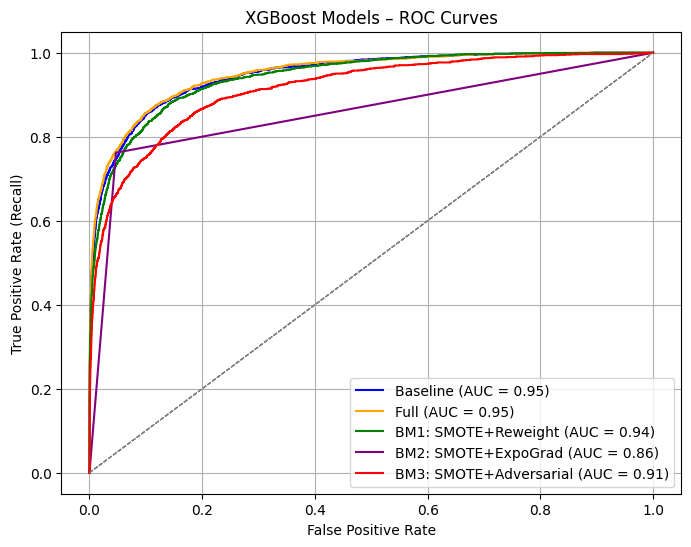


Baseline
Best threshold based on F1 score: 0.304
Precision: 0.717, Recall: 0.682, F1: 0.699

Full
Best threshold based on F1 score: 0.420
Precision: 0.791, Recall: 0.650, F1: 0.714

BM1: SMOTE+Reweight
Best threshold based on F1 score: 0.824
Precision: 0.678, Recall: 0.661, F1: 0.669

BM2: SMOTE+ExpoGrad
Best threshold based on F1 score: 1.000
Precision: 0.592, Recall: 0.762, F1: 0.666

BM3: SMOTE+Adversarial
Best threshold based on F1 score: 0.845
Precision: 0.676, Recall: 0.578, F1: 0.623


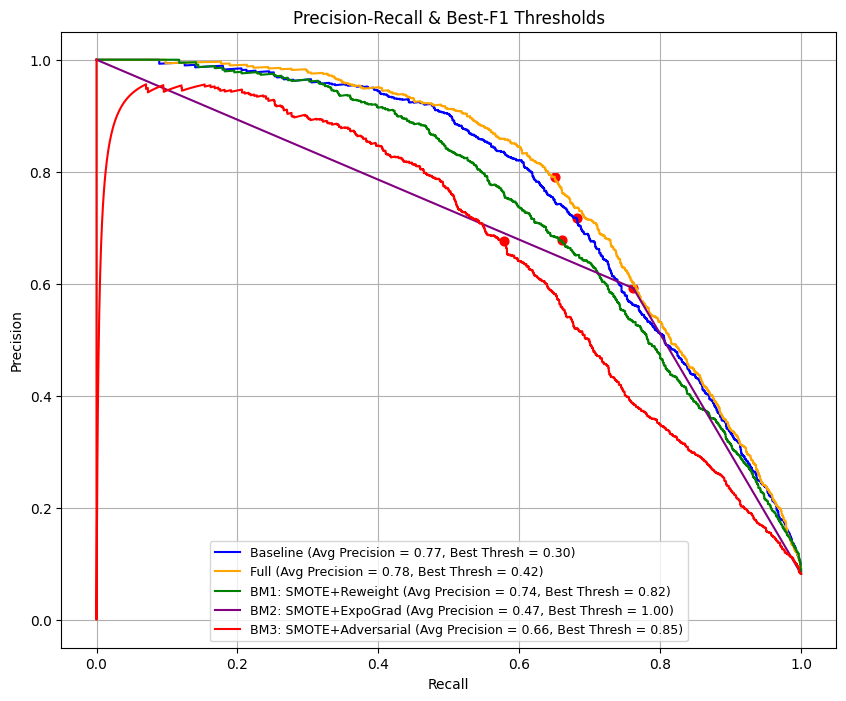

In [ ]:
# --- 1) ROC & PR / Best Thresholds (Finalize) ---
fig, ax = plt.subplots(figsize=(8,6))

# ROC curves
for (y_true, y_scores, label, color) in [
    (yte_b, y_proba_b,   'Baseline',               'blue'),
    (yte_f, y_proba_f,   'Full',                   'orange'),
    (y_te1, y_proba_bm1, 'BM1: SMOTE+Reweight',    'green'),
    (y_te2, y_proba_bm2, 'BM2: SMOTE+ExpoGrad',    'purple'),
    (y_te3, y_proba_bm3, 'BM3: SMOTE+Adversarial', 'red'),
]:
    _, _ = plot_roc_auc(
        y_true=y_true,
        y_scores=y_scores,
        label=label,
        color=color,
        ax=ax
    )
ax.legend(); ax.set_title("XGBoost Models – ROC Curves"); plt.show()

fig, ax = plt.subplots(figsize=(10,8))
# PR curves + best‐F1 thresholds
best_info = {}
for (y_true, y_scores, label, color) in [
    (yte_b, y_proba_b,   'Baseline',               'blue'),
    (yte_f, y_proba_f,   'Full',                   'orange'),
    (y_te1, y_proba_bm1, 'BM1: SMOTE+Reweight',    'green'),
    (y_te2, y_proba_bm2, 'BM2: SMOTE+ExpoGrad',    'purple'),
    (y_te3, y_proba_bm3, 'BM3: SMOTE+Adversarial', 'red'),
]:
    th, _, _, f1, _ = plot_pr_and_find_best_threshold(
        y_true=y_true,
        y_scores=y_scores,
        label=label,
        color=color,
        ax=ax
    )
    best_info[label] = {'threshold': th, 'f1': f1}
ax.legend(fontsize=9)
ax.set_title("Precision‑Recall & Best‑F1 Thresholds"); ax.grid(True)
plt.show()

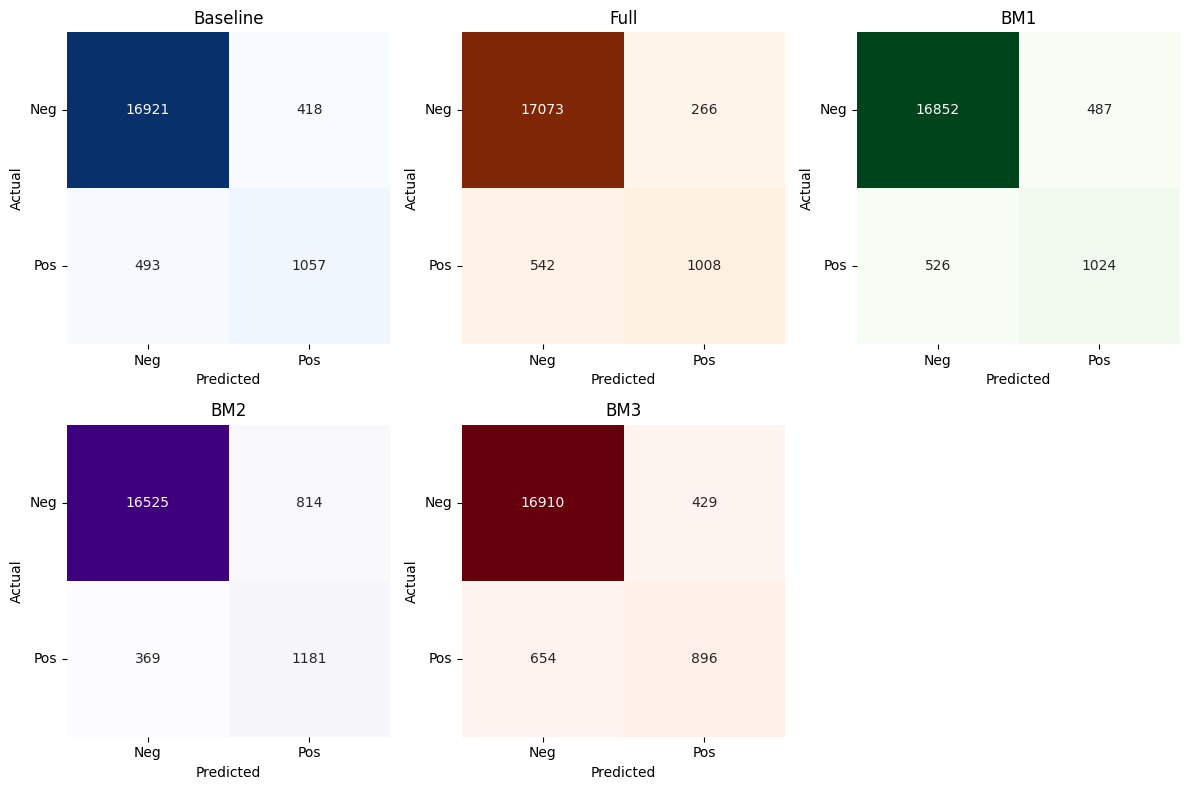

In [51]:
# --- Confusion Matrices ---
cms = [
    (yte_b, best_info['Baseline']['threshold'], Xte_b_s,   'Blues',   'Baseline'),
    (yte_f, best_info['Full']['threshold'], Xte_f_s,   'Oranges', 'Full'),
    (y_te1, best_info['BM1: SMOTE+Reweight']['threshold'], X_te1_s, 'Greens', 'BM1'),
    (y_te2, best_info['BM2: SMOTE+ExpoGrad']['threshold'], X_te2_s, 'Purples','BM2'),
    (y_te3, best_info['BM3: SMOTE+Adversarial']['threshold'], X_te3_s, 'Reds',    'BM3'),
]

fig, axs = plt.subplots(2, 3, figsize=(12,8))

for ax, item in zip(axs.flatten(), cms + [None]):
    if item is None:
        ax.axis('off')
        continue

    # now unpack only if it's not None
    y_true, th, X_test, cmap, title = item

    # pick out the right y_proba vector
    if "BM" in title:
        y_proba = locals()['y_proba_' + title.lower()]
    else:
        y_proba = locals()['y_proba_' + title.lower()[0]]

    y_pred = (y_proba >= th).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Neg','Pos'])
    ax.set_yticklabels(['Neg','Pos'], rotation=0)

plt.tight_layout()
plt.show()


#### Fairness Diagnosis

In [53]:
# build df_test for each model
df_test_b = create_df_test(df, Xte_b,   yte_b,   y_pred_b,   y_proba_b)
df_test_f = create_df_test(df, Xte_f,   yte_f,   y_pred_f,   y_proba_f)
df_test_bm1 = create_df_test(df, X_te1,   y_te1,   y_pred_bm1, y_proba_bm1)
df_test_bm2 = create_df_test(df, X_te2,   y_te2,   y_pred_bm2, y_proba_bm2)
df_test_bm3 = create_df_test(df, X_te3,   y_te3,   y_pred_bm3, y_proba_bm3)

# collect group‐level metrics
reports = {}
for name, df_t in zip(
    ['Baseline','Full','bm1','bm2','bm3'],
    [df_test_b, df_test_f, df_test_bm1, df_test_bm2, df_test_bm3]
):
    reports[name] = {
        'gender': get_group_metrics(df_t, 'gender_group'),
        'age': get_group_metrics(df_t, 'age_group'),
        'race': get_group_metrics(df_t, 'race_group'),
    }

# concatenate for plotting
gender_comp = pd.concat([reports[m]['gender'].assign(model=m) for m in reports])
age_comp = pd.concat([reports[m]['age']. assign(model=m) for m in reports])
race_comp = pd.concat([reports[m]['race']. assign(model=m) for m in reports])


##### Equal Opportunity

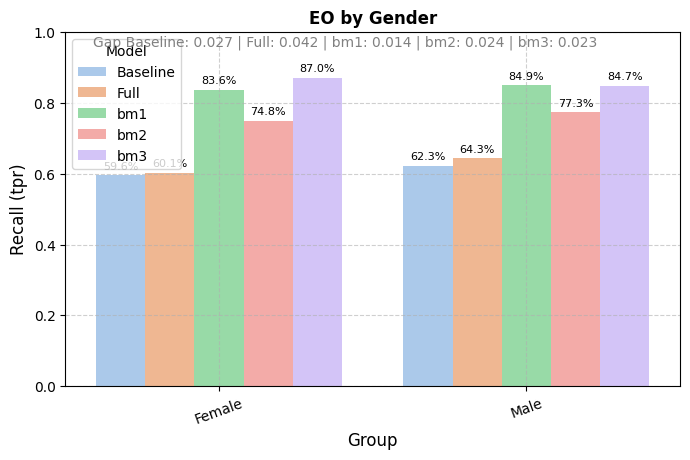

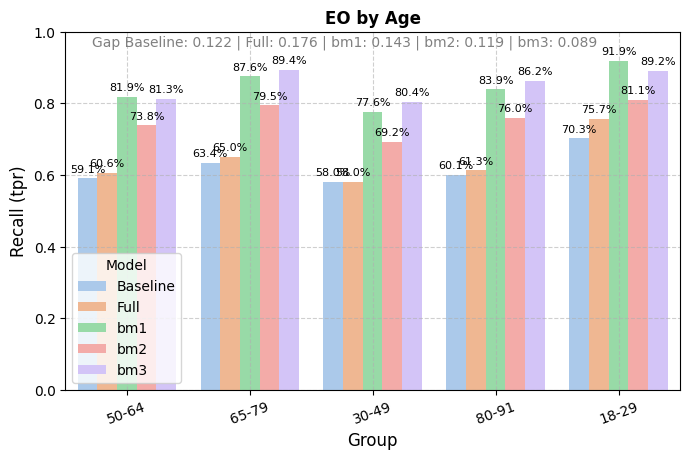

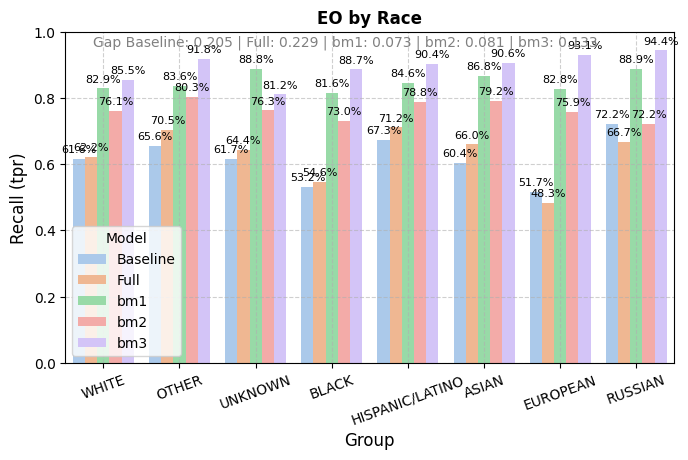

In [58]:
gender_eo_dict = plot_equal_opportunity(gender_comp, metric='recall (TPR)', title='EO by Gender')
age_eo_dict = plot_equal_opportunity(age_comp, metric='recall (TPR)', title='EO by Age')
race_eo_dict = plot_equal_opportunity(race_comp, metric='recall (TPR)', title='EO by Race')

##### Statistical Parity

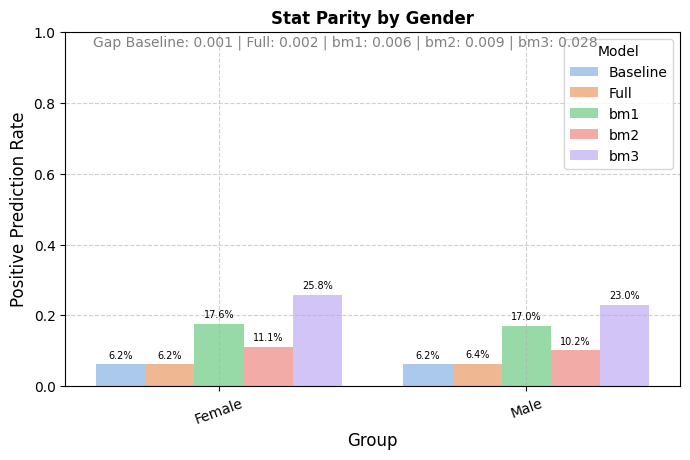

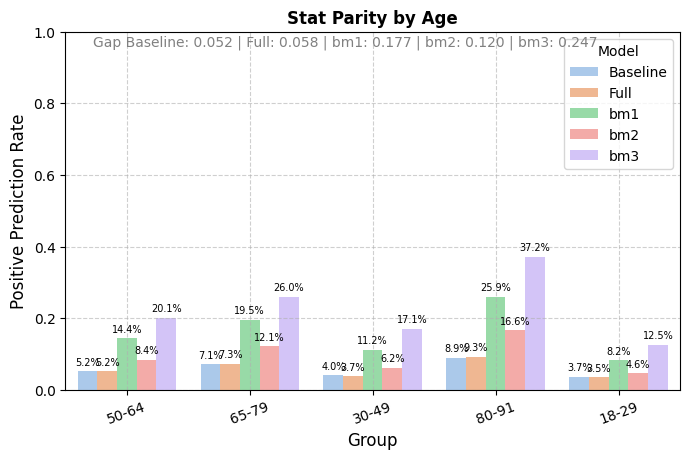

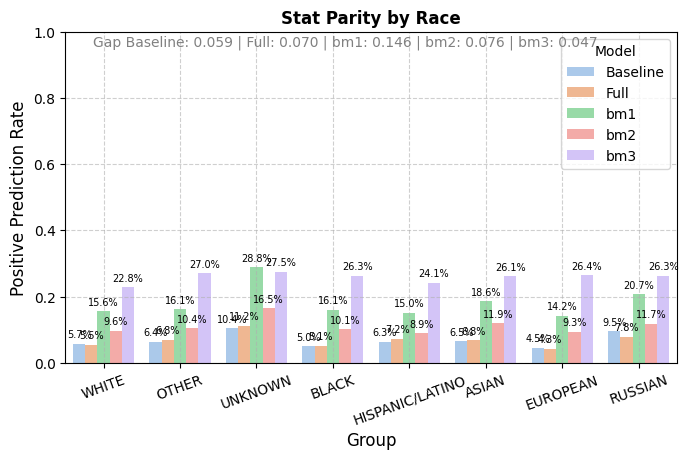

In [59]:
gender_ppr_dict = plot_statistical_parity(gender_comp, title='Stat Parity by Gender')
age_ppr_dict = plot_statistical_parity(age_comp, title='Stat Parity by Age')
race_ppr_dict = plot_statistical_parity(race_comp, title='Stat Parity by Race')

##### Equalized Odds

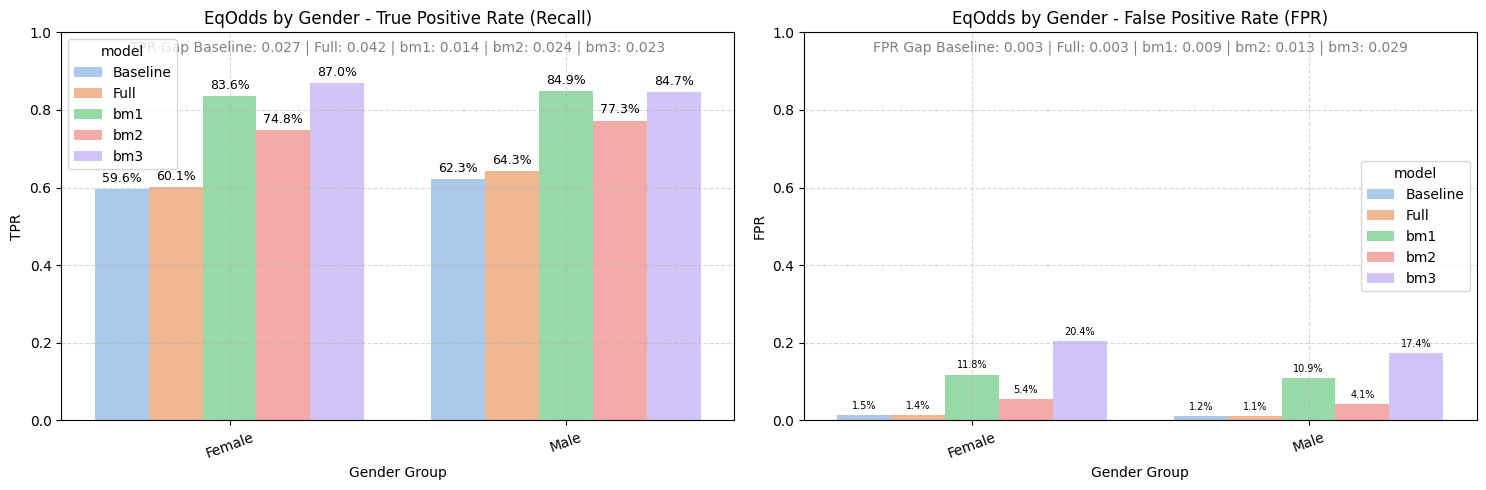

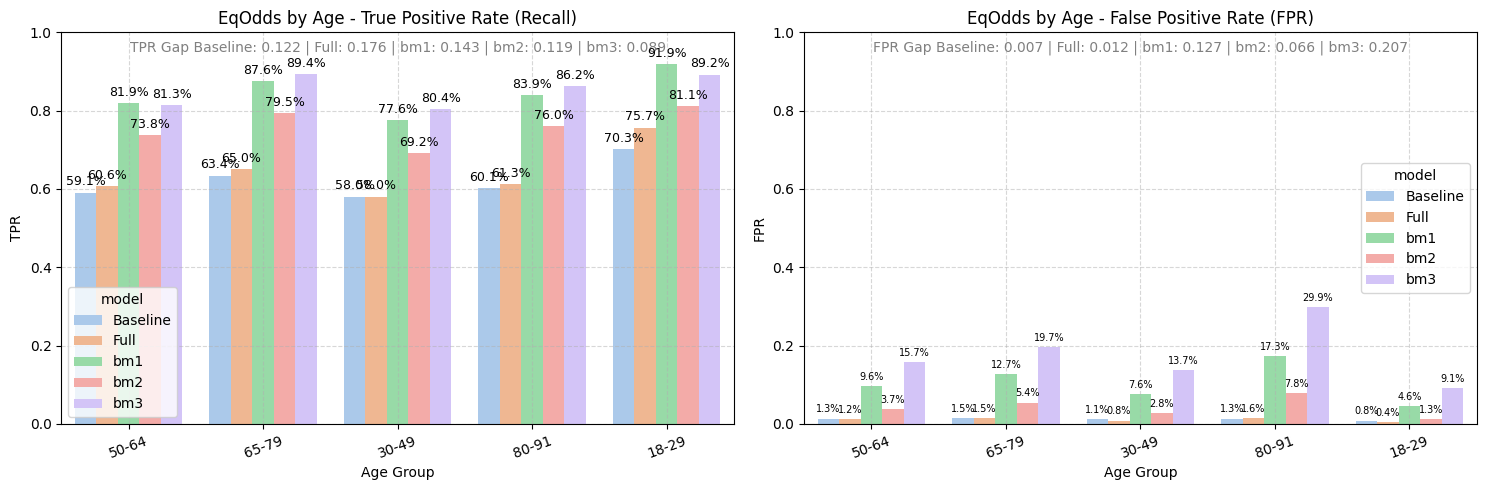

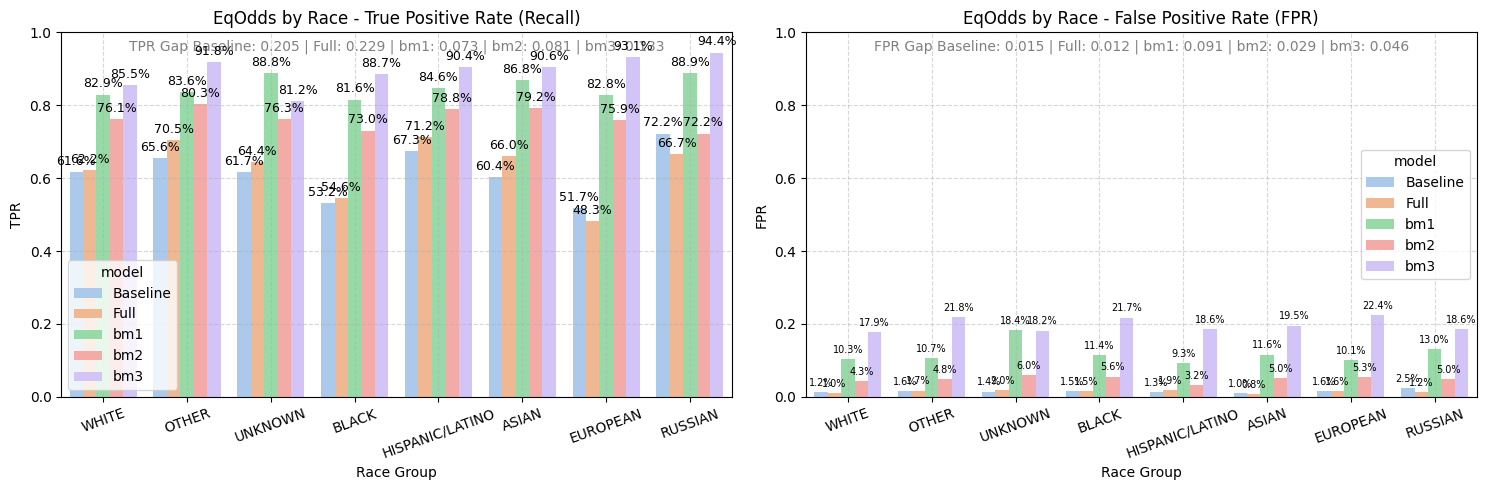

In [57]:
gender_tpr_dict, gender_fpr_dict = plot_equalized_odds(gender_comp, 'Gender Group', title_prefix='EqOdds by Gender')
age_tpr_dict, age_fpr_dict = plot_equalized_odds(age_comp, 'Age Group', title_prefix='EqOdds by Age')
race_tpr_dict, race_fpr_dict = plot_equalized_odds(race_comp, 'Race Group', title_prefix='EqOdds by Race')

##### Calibration

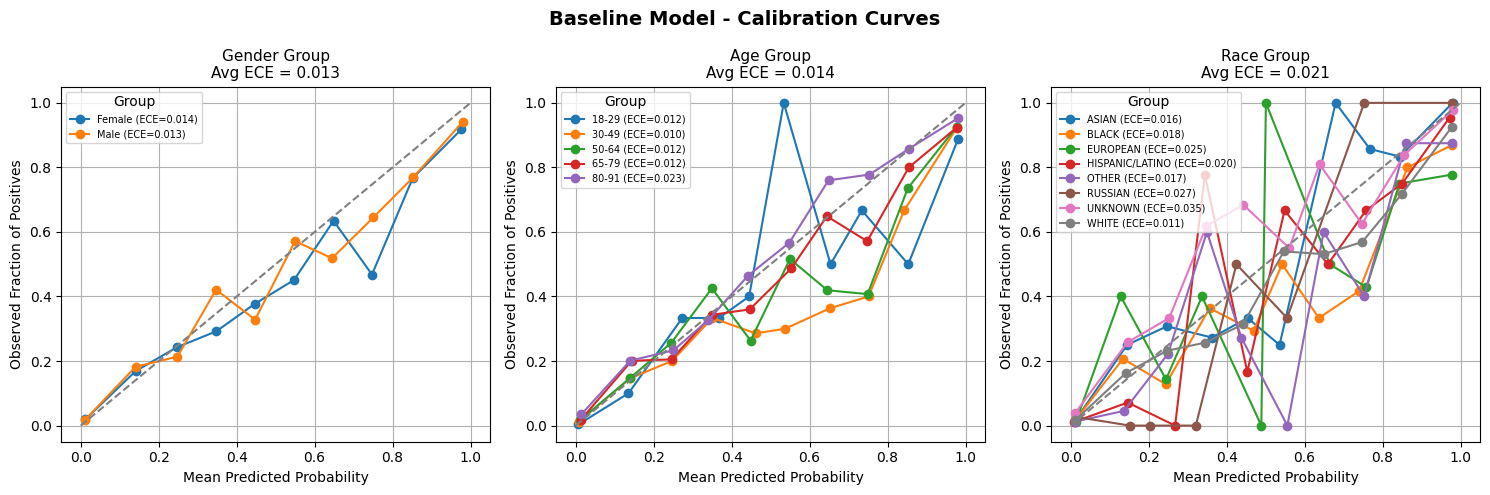

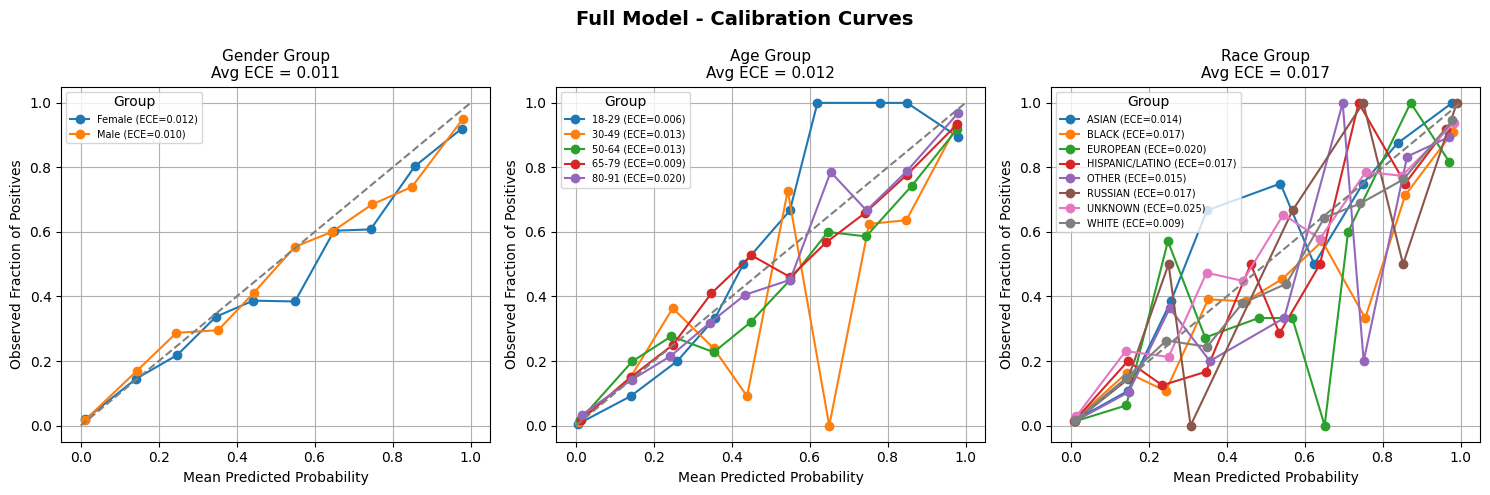

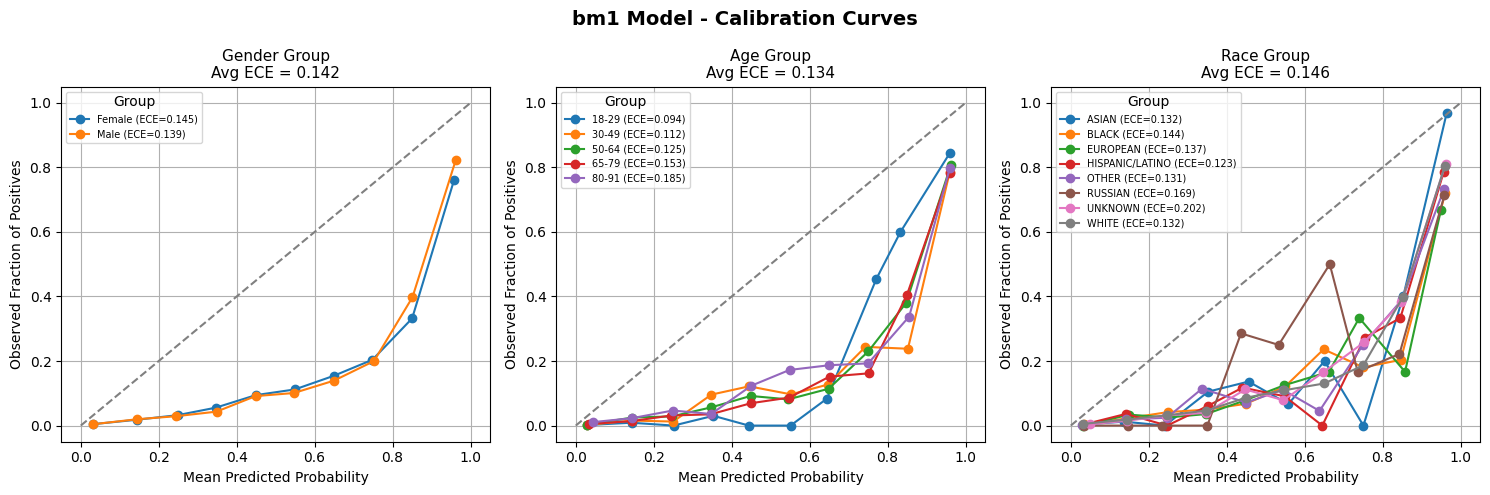

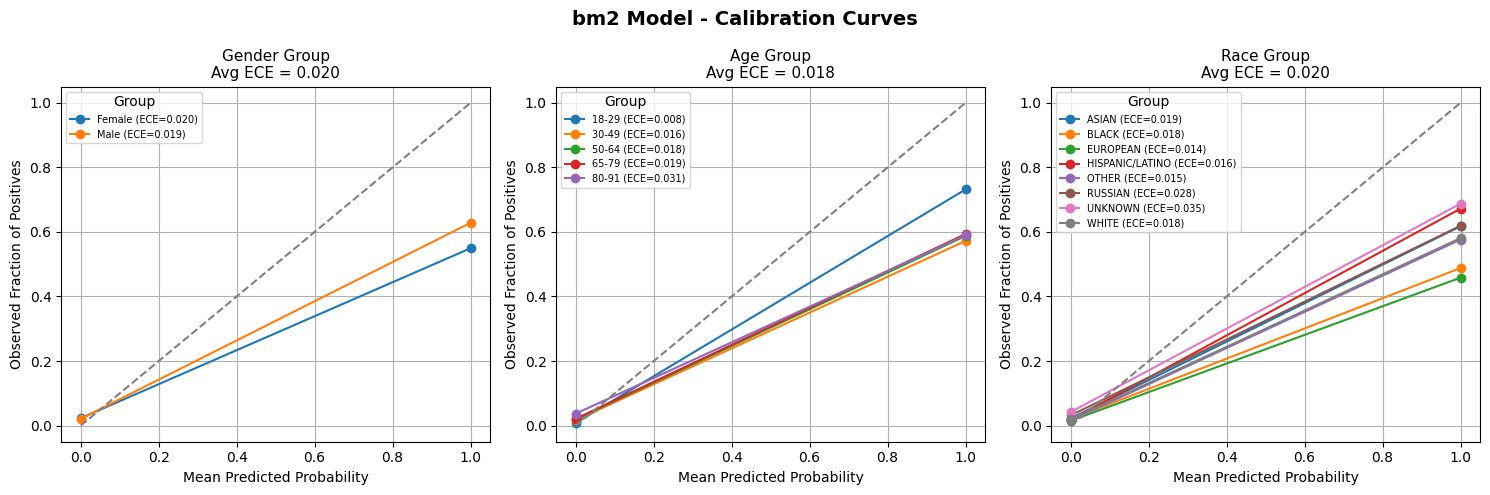

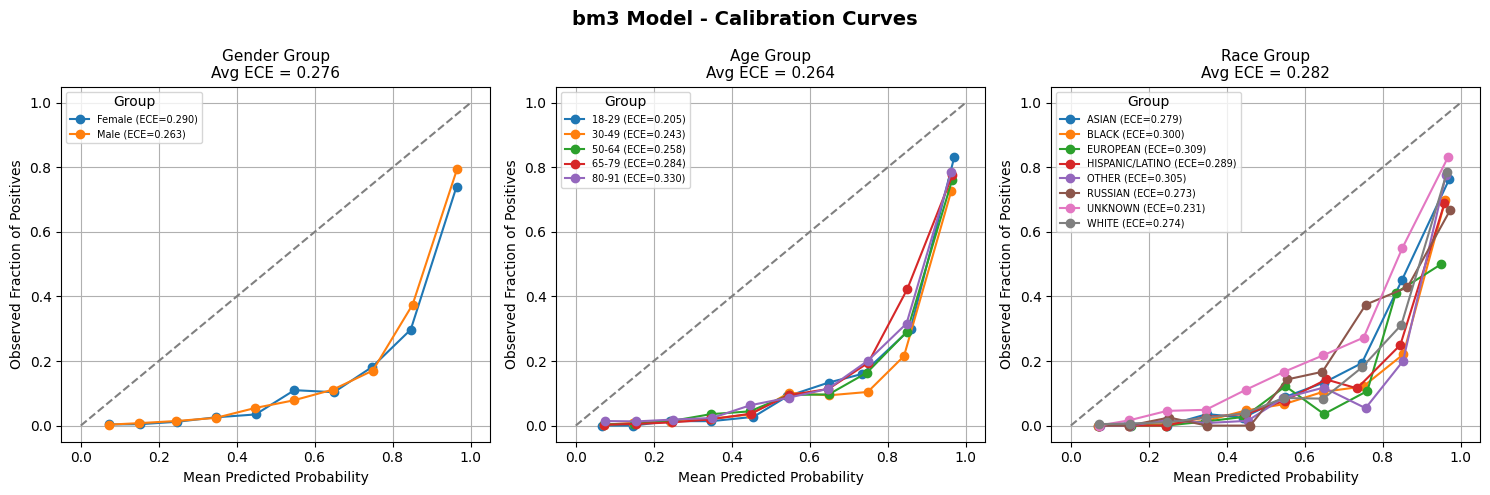

In [ ]:
# --- Calibration (ECE) with named avg_subgroup_ece ---
model_labels = ['Baseline', 'Full', 'bm1', 'bm2', 'bm3']
df_tests     = [df_test_b,   df_test_f,   df_test_bm1,   df_test_bm2,   df_test_bm3]

avg_subgroup_ece_list = []
for df_t, label in zip(df_tests, model_labels):
    avg_ece_dict = plot_calibration_ece(df=df_t, model_label=label)
    avg_subgroup_ece_list.append((label, avg_ece_dict))

# convert to a dict
avg_subgroup_ece = dict(avg_subgroup_ece_list)

#### 	Fairness-Performance Tradeoff Analysis

C:\Users\Cynthia\AppData\Local\Temp\ipykernel_18076\372623016.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Δ F1', data=df_f1, palette='pastel')


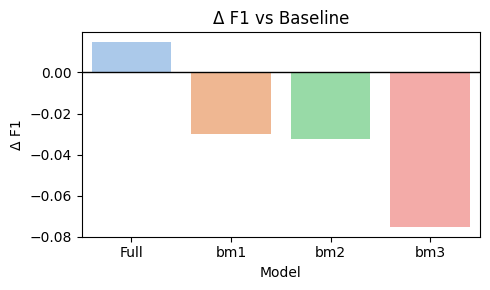

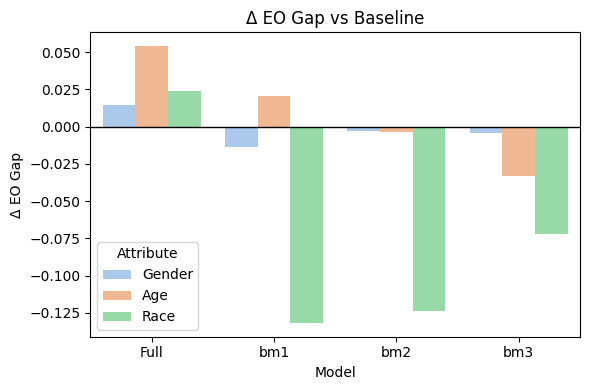

In [ ]:
models = ['Full', 'bm1', 'bm2', 'bm3']
# mapping concise -> best_info keys
long_map = {
    'Full': 'Full',
    'bm1':  'BM1: SMOTE+Reweight',
    'bm2':  'BM2: SMOTE+ExpoGrad',
    'bm3':  'BM3: SMOTE+Adversarial'
}
baseline_f1 = best_info['Baseline']['f1']

# Δ F1 vs Baseline
df_f1 = pd.DataFrame({
    'Model': models,
    'Δ F1': [best_info[long_map[m]]['f1'] - baseline_f1 for m in models]
})
plt.figure(figsize=(5,3))
sns.barplot(x='Model', y='Δ F1', data=df_f1, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ F1 vs Baseline')
plt.tight_layout()
plt.show()

# Build tradeoff DataFrames
tradeoff_dfs = []
for attr, eo_d, ppr_d, tpr_d, fpr_d in [
    ('Gender', gender_eo_dict, gender_ppr_dict, gender_tpr_dict, gender_fpr_dict),
    ('Age',    age_eo_dict,    age_ppr_dict,    age_tpr_dict,    age_fpr_dict),
    ('Race',   race_eo_dict,   race_ppr_dict,   race_tpr_dict,   race_fpr_dict),
]:
    rows = []
    for m in ['Baseline'] + models:
        rows.append({
            'Model':         m,
            'Attribute':     attr,
            'Δ EO Gap':      eo_d[m]  - eo_d['Baseline'],
            'Δ PPR Gap':     ppr_d[m] - ppr_d['Baseline'],
            'Δ TPR Gap':     tpr_d[m] - tpr_d['Baseline'],
            'Δ FPR Gap':     fpr_d[m] - fpr_d['Baseline'],
            'ECE':           avg_subgroup_ece[m][f'{attr.lower()}_group'],
            'F1':            best_info[ long_map.get(m, 'Baseline') ]['f1'] if m!='Baseline' else baseline_f1
        })
    df_tmp = pd.DataFrame(rows).query("Model != 'Baseline'")
    df_tmp['Fairness Total'] = df_tmp[['Δ EO Gap','Δ PPR Gap','Δ TPR Gap','Δ FPR Gap','ECE']].sum(axis=1)
    df_tmp['Fairness Index'] = 1 / (1 + df_tmp['Fairness Total'])
    tradeoff_dfs.append(df_tmp)

fairness_df = pd.concat(tradeoff_dfs, ignore_index=True)

# Δ EO Gap bar
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Δ EO Gap', hue='Attribute', data=fairness_df, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ EO Gap vs Baseline')
plt.tight_layout()
plt.show()

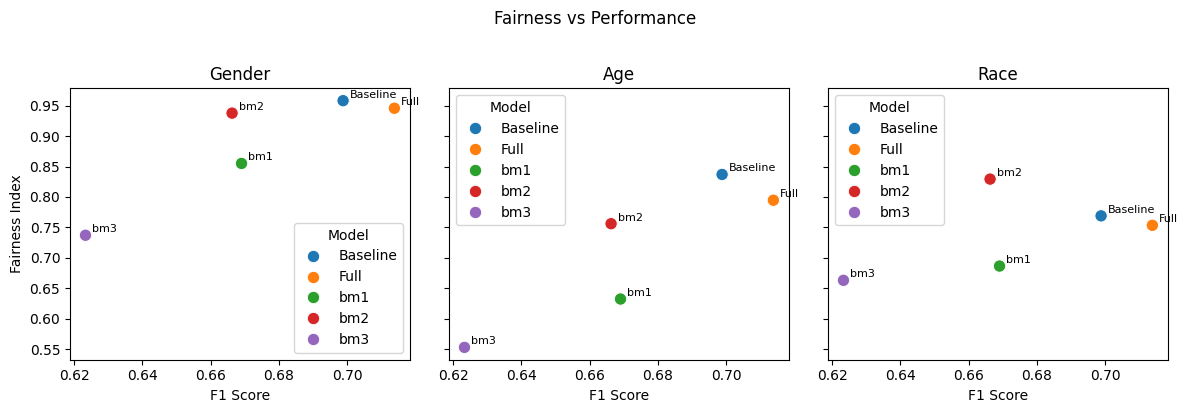

In [ ]:
# Fairness Index vs F1 scatter
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharey=True)
for ax, attr in zip(axes, ['Gender','Age','Race']):
    sub = fairness_df[fairness_df['Attribute']==attr]
    sns.scatterplot(data=sub, x='F1', y='Fairness Index', hue='Model', s=80, ax=ax)
    for _, r in sub.iterrows():
        ax.text(r['F1']+0.002, r['Fairness Index']+0.005, r['Model'], fontsize=8)
    ax.set_title(f'{attr}')
    ax.set_xlabel('F1 Score')
    ax.set_ylabel('Fairness Index' if attr=='Gender' else '')
fig.suptitle('Fairness vs Performance', y=1.02)
plt.tight_layout()
plt.show()
